# Install Library

In [ ]:
!pip -q install transformers

# Import Library

In [ ]:
import numpy as np
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Concatenate
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import EarlyStopping

# Mount Gdrive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/ABSA_Training_New_1/train.csv"
VALID_PATH = "/content/drive/MyDrive/ABSA_Training_New_1/validation.csv"
TEST_PATH  = "/content/drive/MyDrive/ABSA_Training_New_1/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
valid_df = pd.read_csv(VALID_PATH)
test_df = pd.read_csv(TEST_PATH)

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(6368, 7)
(796, 7)
(797, 7)


In [ ]:
train_df = train_df.dropna(subset=["sentiment"])
valid_df = valid_df.dropna(subset=["sentiment"])
test_df = test_df.dropna(subset=["sentiment"])

# Training, Testing, Validating

In [ ]:
def split_context(review, aspect):

    review = str(review)

    aspect = str(aspect)

    idx = review.lower().find(
        aspect.lower()
    )

    if idx == -1:

        return review, "", ""

    left = review[:idx]

    right = review[idx+len(aspect):]

    return left, aspect, right

In [ ]:
train_df[
    [
        "left",
        "aspect_term",
        "right"
    ]
] = train_df.apply(

    lambda x:

    split_context(

        x["text"],

        str(x["keywords"]).split(",")[0]

    ),

    axis=1,

    result_type="expand"

)

In [ ]:
valid_df[
    [
        "left",
        "aspect_term",
        "right"
    ]
] = valid_df.apply(

    lambda x:

    split_context(

        x["text"],

        str(x["keywords"]).split(",")[0]

    ),

    axis=1,

    result_type="expand"

)

In [ ]:
test_df[
    [
        "left",
        "aspect_term",
        "right"
    ]
] = test_df.apply(

    lambda x:

    split_context(

        x["text"],

        str(x["keywords"]).split(",")[0]

    ),

    axis=1,

    result_type="expand"

)

In [ ]:
train_df[
    [
        "text",
        "keywords",
        "left",
        "aspect_term",
        "right"
    ]
].head(10)

,text,keywords,left,aspect_term,right
0,sungguh disayangkan fitur kirim koin di hilang...,acak,sungguh disayangkan fitur kirim koin di hilang...,acak,-acakan atau malah lebih buruk. kadang buka ap...
1,semoga lebih banyak lagi bagi koin nya,koin,semoga lebih banyak lagi bagi,koin,nya
2,"koin nonton live tdk masuk ke tabungan koin ,m...",koin,,koin,"nonton live tdk masuk ke tabungan koin ,mohon..."
3,bagus beragam jenis voucher game untuk mengump...,voucher game,bagus beragam jenis,voucher game,untuk mengumpulkan koin dan shoppe pay untuk ...
4,"aplikasi oon, udah smpe di titik tujuan cs tid...",poin,"aplikasi oon, udah smpe di titik tujuan cs tid...",poin,"pelanggaran 150 auto pm, dia yg buat peratura..."
5,sy member gold shopee. tp skrg terpaksa uninst...,kecewa,sy member gold shopee. tp skrg terpaksa uninst...,kecewa,terutama video shopee. isinya seperti akun go...
6,saya jengkel sama admin shoppe yg menyembunyik...,coin,saya jengkel sama admin shoppe yg menyembunyik...,coin,pun ditarik !!! busuknya kebijakan tolol shop...
7,lebih tingkat lagi koin y,koin,lebih tingkat lagi,koin,y
8,"gara gara cocoki nya susah, pacar saya kesel nih",cocoki,gara gara,cocoki,"nya susah, pacar saya kesel nih"
9,"main shopee game, menang 200jt, ujungnya terim...",shopee game,main,shopee game,", menang 200jt, ujungnya terima 2 ribu.."


In [ ]:
all_text = pd.concat([
    train_df["left"],
    train_df["aspect_term"],
    train_df["right"]
]).astype(str)

tokenizer = Tokenizer(
    num_words=30000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(all_text)

word_index = tokenizer.word_index

print("Vocabulary Size :", len(word_index))

Vocabulary Size : 8781


In [ ]:
X_left_train = tokenizer.texts_to_sequences(
    train_df["left"].astype(str)
)

X_aspect_train = tokenizer.texts_to_sequences(
    train_df["aspect_term"].astype(str)
)

X_right_train = tokenizer.texts_to_sequences(
    train_df["right"].astype(str)
)

In [ ]:
X_left_valid = tokenizer.texts_to_sequences(
    valid_df["left"].astype(str)
)

X_aspect_valid = tokenizer.texts_to_sequences(
    valid_df["aspect_term"].astype(str)
)

X_right_valid = tokenizer.texts_to_sequences(
    valid_df["right"].astype(str)
)

In [ ]:
X_left_test = tokenizer.texts_to_sequences(
    test_df["left"].astype(str)
)

X_aspect_test = tokenizer.texts_to_sequences(
    test_df["aspect_term"].astype(str)
)

X_right_test = tokenizer.texts_to_sequences(
    test_df["right"].astype(str)
)

In [ ]:
MAX_LEN = 100

from tensorflow.keras.preprocessing.sequence import pad_sequences

X_left_train = pad_sequences(
    X_left_train,
    maxlen=MAX_LEN,
    padding="post"
)

X_aspect_train = pad_sequences(
    X_aspect_train,
    maxlen=10,
    padding="post"
)

X_right_train = pad_sequences(
    X_right_train,
    maxlen=MAX_LEN,
    padding="post"
)

In [ ]:
X_left_valid = pad_sequences(
    X_left_valid,
    maxlen=MAX_LEN,
    padding="post"
)

X_aspect_valid = pad_sequences(
    X_aspect_valid,
    maxlen=10,
    padding="post"
)

X_right_valid = pad_sequences(
    X_right_valid,
    maxlen=MAX_LEN,
    padding="post"
)

In [ ]:
X_left_test = pad_sequences(
    X_left_test,
    maxlen=MAX_LEN,
    padding="post"
)

X_aspect_test = pad_sequences(
    X_aspect_test,
    maxlen=10,
    padding="post"
)

X_right_test = pad_sequences(
    X_right_test,
    maxlen=MAX_LEN,
    padding="post"
)

In [ ]:
y_train = train_df["sentiment_label"].values

y_valid = valid_df["sentiment_label"].values

y_test = test_df["sentiment_label"].values

In [ ]:
print(X_left_train.shape)

print(X_aspect_train.shape)

print(X_right_train.shape)

print(y_train.shape)

(6368, 100)
(6368, 10)
(6368, 100)
(6368,)


In [ ]:
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Concatenate
)

from tensorflow.keras.models import Model

# Tokenizing

In [ ]:
VOCAB_SIZE = len(tokenizer.word_index) + 1

EMBED_DIM = 128

left_input = Input(
    shape=(100,),
    name="left_input"
)

right_input = Input(
    shape=(100,),
    name="right_input"

)

Word Embedding

In [ ]:
embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM
)

left_embed = embedding(left_input)

right_embed = embedding(right_input)

In [ ]:
left_lstm = LSTM(
    128
)(left_embed)

right_lstm = LSTM(
    128,
    go_backwards=True
)(right_embed)

In [ ]:
merged = Concatenate()([
    left_lstm,
    right_lstm
])

x = Dropout(0.5)(merged)

x = Dense(
    64,
    activation="relu"
)(x)

output = Dense(
    3,
    activation="softmax"
)(x)

# Model Summary

In [ ]:
model = Model(
    inputs=[
        left_input,
        right_input
    ],
    outputs=output
)

model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ left_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 128)  │  1,124,096 │ left_input[0][0], │
│ (Embedding)         │                   │            │ right_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │    131,584 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 128)       │    131,584 │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,403,907 (5.36 MB)

 Trainable params: 1,403,907 (5.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5636395822269428), np.int64(1): np.float64(8.918767507002801), np.int64(2): np.float64(0.8979131415679639)}


# Training

In [ ]:
history = model.fit(

    x=[
        X_left_train,
        X_right_train
    ],

    y=y_train,

    validation_data=(
        [
            X_left_valid,
            X_right_valid
        ],
        y_valid
    ),

    epochs=15,

    batch_size=32,

    callbacks=[early_stop],

    class_weight=class_weights
)

Epoch 1/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 72s 365ms/step - accuracy: 0.8651 - loss: 0.3609 - val_accuracy: 0.7613 - val_loss: 0.6626
Epoch 2/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 68s 341ms/step - accuracy: 0.8843 - loss: 0.3057 - val_accuracy: 0.7224 - val_loss: 0.6244
Epoch 3/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 72s 363ms/step - accuracy: 0.8997 - loss: 0.2555 - val_accuracy: 0.7877 - val_loss: 0.6716


In [ ]:
y_pred_prob = model.predict([
    X_left_test,
    X_right_test
])

y_pred = np.argmax(y_pred_prob, axis=1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step


# Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print(classification_report(y_test, y_pred))

Accuracy : 0.7478042659974906
Precision: 0.810240069515341
Recall   : 0.7478042659974906
F1 Score : 0.7676428601952858
              precision    recall  f1-score   support

           0       0.91      0.71      0.80       471
           1       0.15      0.43      0.23        30
           2       0.72      0.84      0.78       296

    accuracy                           0.75       797
   macro avg       0.59      0.66      0.60       797
weighted avg       0.81      0.75      0.77       797



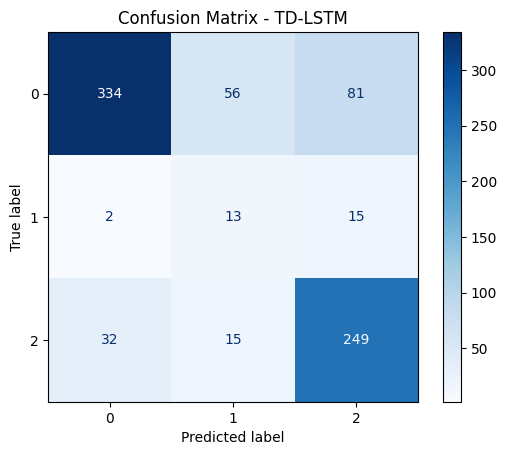

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - TD-LSTM")
plt.show()

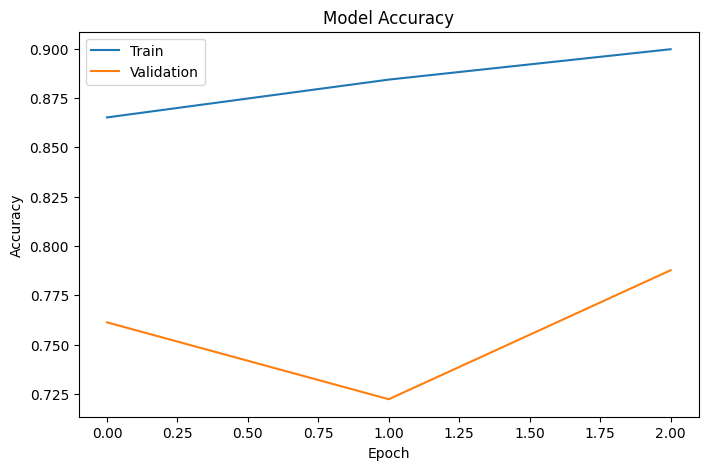

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

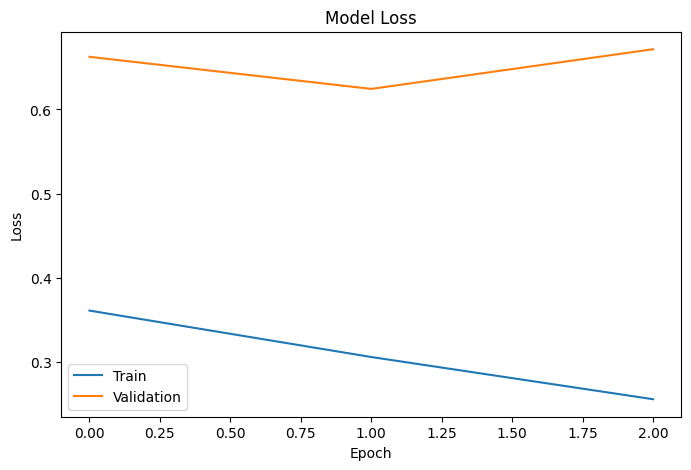

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()